## Introduction

Infographics, or a thoughtful visual representation of data and information, can be powerful tools to convey a message effectively. Appealing designs grab the viewer's attention, and the intuitive charts and graphs make the main message easy to understand and remember. 

There are many aspects that go into an infographic. Some elements, especially those pertaining to the graphs, can actually be done inside Python scripts. 

In this blog post, I explain how to incorporate [icons from Font Awesome](https://fontawesome.com/) into `matplotlib` figures as text and path objects. In general, [treating icons as text](#sec-icon-text) is simpler, and suffices when plotting only a couple icons. On the other hand, if you want to use the icons in scatter plots, it is advisable to [convert icons into paths](#sec-icon-path).

### What You'll Learn in this Tutorial

By the end of this short tutorial, you'll learn how to:

- **Draw Font Awesome icons as text objects** with `matplotlib.pyplot.text()` 
- **Convert Font Awesome icons to paths** for plotting with `matplotlib.pyplot.scatter()`
- **Make graphs with icons**
- **Apply an image overlay to icons** with clipping

If you prefer to skip the explanations and jump straight to the implementation, you can [download the code from my GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/plotting-icons/). 

Here is the list of things you'll need to run the code.

### Prerequisites

- A copy of either the `plotting-icons.ipynb` Jupyter notebook or `plotting-icons.py` Python script from my [GitHub repository](https://github.com/DataDrivenMai/DataDrivenMai-blog/tree/main/plotting-icons)
- Python libraries
    - `matplotlib`

### Jargon

**Unicode**: An international standard for character and emoji encoding. It allows screens to display characters whether it be written in English, French, Japanese or Hebrew. 

**Path**: The `matplotlib.path` objects, or similar `matplotlib.textpath` objects.

**Bounding box**: 

**Clipping**: 

## Download the Font Awesome Package for Desktop

There are several methods to make the Font Awesome icons usable in the Python environment. I find [downloading Font Awesome package for desktop](https://fontawesome.com/download) to the `data\` subdirectory to be quick and intuitive. If you download the free package like I did, you should end up with three OTF files with `'Brands-Regular'`, `'Free-Regular'` and `'Free-Solid'` in the file names.

At the time of writing this blog (May 2026), the Font Awesome package is version 7.2.0, as indicated by `'Font Awesome 7'` in the three extracted OTF files. If you are downloading after a version update, the file names will differ from the ones I've provided below.


In [5]:
# Path to your downloaded Font Awesome OTF file
font_path_brands = "./data/Font Awesome 7 Brands-Regular-400.otf"
font_path_regular = "./data/Font Awesome 7 Free-Regular-400.otf"
font_path_solid = "./data/Font Awesome 7 Free-Solid-900.otf"

We also need the `matplotlib.font_manager.FontProperties` class to store information about each Font Awesome icon groups.

In [6]:
# Import the FontProperties class from matplotlib.font_manager
from matplotlib.font_manager import FontProperties

Store the font properties of each OTF file for use when displaying the icons. 

In [7]:
# Create FontProperties objects for each of the Font Awesome OTF files
fp_brands = FontProperties(fname=font_path_brands)
fp_regular = FontProperties(fname=font_path_regular)
fp_solid = FontProperties(fname=font_path_solid)

We can now choose the icon we'd like to use in our Python projects. 

## Find the Unicode of Your Chosen Icons

To use Font Awesome icons in your Python projects, you will need to know the icon's

- Unicode identifier
- Font package that it belongs to

Both can be found on the Font Awesome website. 

For example, Font Awesome's lightbulb icon has two variants: the [regular lightbulb design](https://fontawesome.com/icons/classic/regular/lightbulb) and the [solid lightbulb design](https://fontawesome.com/icons/classic/solid/lightbulb). The Unicode identifier can be found in the top right corner (as indicated by the blue box in @fig-lightbulbs), while the Font Awesome font package can be found within the HTML class (as shown by the orange box in @fig-lightbulbs), or within the HTML address of the icon. You'll notice that the lightbulb icon variants have the same Unicode identifier of f0eb, but belong to different font packages.

::: {#fig-lightbulbs layout-ncol=2}

![Regular lightbulb icon](./images/lightbulb-regular.png){#fig-lightbulb-regular}

![Solid lightbulb icon](./images/lightbulb-solid.png){#fig-lightbulb-solid}

Unicode identifier (top right blue box) and font package (orange box) for two lightbulb icon variants in Font Awesome
:::

To use the icons in Python, we will be be using the escape sequence of `'\u'` to indicate that the item we are dealing with is a Unicode identifier. In the case of the regular lightbulb icon, the Python code will be `'\uf0eb'`.

The chosen icons can now be used as text objects. 

## Drawing Icons on Plots as Text{#sec-icon-text}

In the previous section, we saw that [icons from Font Awesome](https://fontawesome.com/) are treated as characters, each with its own unique [Unicode identifier](https://home.unicode.org/). As such, the simplest method of drawing icons on a plot are to treat them as text objects, specified by their Unicode.

Let's make a simple dictionary containing five icons from the Font Awesome brands package to call each Unicode using a key. Remember to include the `'\u'` Unicode escape sequence.

In [1]:
# Dictionary of five Font Awesome brand icons
fa_dict = {
    "google": "\uf1a0",
	"apple": "\uf179",
	"meta": "\ue49b",
	"amazon": "\uf270",
	"microsoft": "\uf17a"
}

We'll need the `matplotlib.pyplot` library to make the figures to plot the text upon.

In [2]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

The icons can now be placed in a figure using `plt.text()`. 

### Designate the Location, Size and Color of Icons

The minimal parameters required to place the icons are its

- x coordinate
- y coordinate
- Unicode identifier
- Appropriate font properties

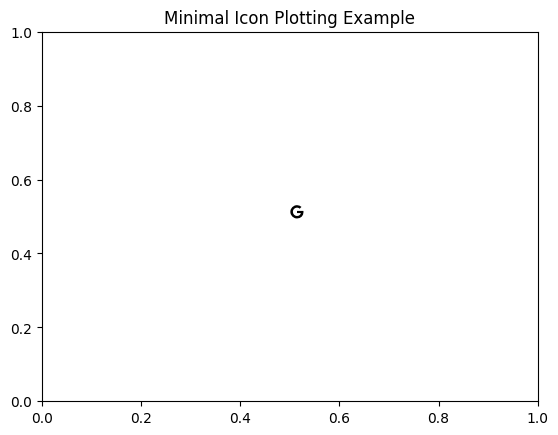

In [23]:
# Make a figure with minimal parameters for icon placement
plt.figure()

# Place the Google icon at the center of the plot using the brands font
plt.text(0.5, 0.5, fa_dict["google"], fontproperties=fp_brands)

# Plot logistics
plt.title("Minimal Icon Plotting Example")
plt.show()

The icon shows up in black at the designated location. Since it is treated like a text object, the default display is rather small. 

### Size

The size of the icons can be changed like any text object using the `fontsize` parameter. The user can designate a relative size such as `'x-small'`, or specify the point size as a floating value.

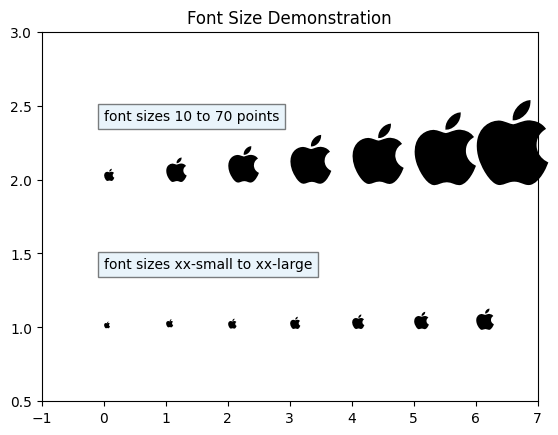

In [39]:
# Relative icon sizes
font_sizes1 = ['xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large']
font_sizes2 = [10, 20, 30, 40, 50, 60, 70]

# Make a figure to demonstrate the different font sizes
plt.figure()

# Plot the relative and absolute font sizes
for i in range(len(font_sizes1)):
	plt.text(i, 1, fa_dict["apple"], fontproperties=fp_brands, fontsize=font_sizes1[i])
	plt.text(i, 2, fa_dict["apple"], fontproperties=fp_brands, fontsize=font_sizes2[i])

# Description
plt.text(0, 1.4, "font sizes xx-small to xx-large", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 2.4, "font sizes 10 to 70 points", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-1, len(font_sizes1))
plt.ylim(0.5, 3.0)
plt.title("Font Size Demonstration")
plt.show()

To make icons visibly large, you'll most likely designate a value for its `fontsize` parameter, rather than use the relative sizes. 

Next, let's try changing the color of the icons

### Color

The icon colors can be designated with named colors like `'red'` or `'blue'`, or precisely through hex codes like `'#22668D'`. If you'd like a gradient of colors, you can use the ones available with `plt.colormaps`.

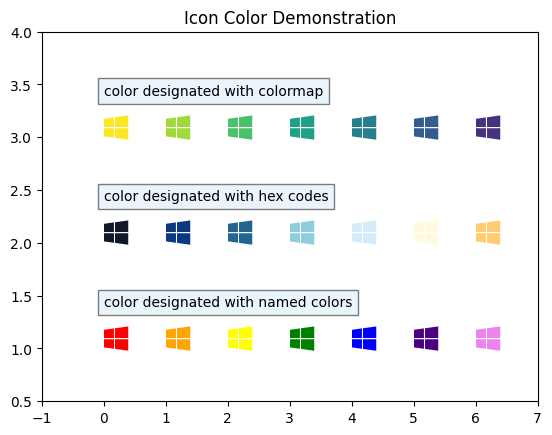

In [ ]:
# Three types of color specifications
font_colors1 = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']
font_colors2 = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
font_colors3 = plt.colormaps['viridis_r']
icon_size = 20

# Make a figure to demonstrate the different icon colors
plt.figure()

# Plot the relative and absolute font sizes
for i in range(len(font_colors1)):
	plt.text(i, 1, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors1[i])
	plt.text(i, 2, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors2[i])
	plt.text(i, 3, fa_dict["microsoft"], fontproperties=fp_brands, fontsize=icon_size, color=font_colors3(i/len(font_colors1)))

# Description
plt.text(0, 1.4, "color designated with named colors", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 2.4, "color designated with hex codes", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0, 3.4, "color designated with colormap", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-1, len(font_colors1))
plt.ylim(0.5, 4.0)
plt.title("Icon Color Demonstration")
plt.show()

We can change the icon size and color. Next is its rotation

### Rotation



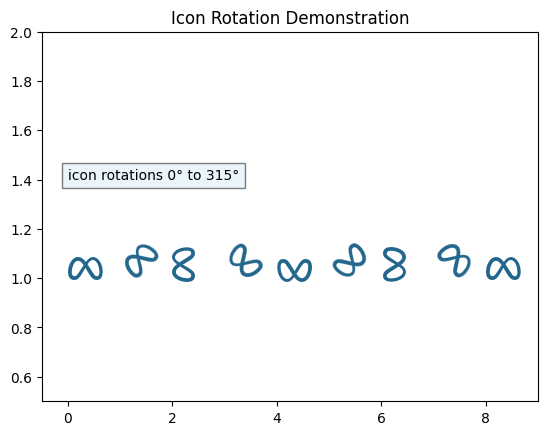

In [ ]:
# Relative icon sizes
icon_rotation = [0, 45, 90, 135, 180, 225, 270, 315, 360]
icon_size = 20
icon_color = '#22668D'

# Make a figure to demonstrate the different font sizes
plt.figure()

# Plot the relative and absolute font sizes
for i in range(len(icon_rotation)):
	plt.text(i, 1, fa_dict["meta"], fontproperties=fp_brands, fontsize=icon_size, color=icon_color, rotation=icon_rotation[i])
	
# Description
plt.text(0, 1.4, "icon rotations 0° to 360°", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(-0.5, len(icon_rotation))
plt.ylim(0.5, 2.0)
plt.title("Icon Rotation Demonstration")
plt.show()

We can now designate the icon size, color and rotation. We will look into the details of its placement location in the next section.

### Horizontal and Vertical Alignment{#sec-ha-va-text}

Knowing how to draw icons at a designated location with a specific size and color meets most user's needs. Add onto that the power to rotate the icon, and you are already well equipped for most tasks. However, knowing how the icons are placed on the the plot further allows you to be even more specific in its placement. 

Let's start by plotting various brand icons with different sizes, colors and rotation values. We will also identify the exact coordinate where each icon was placed. 

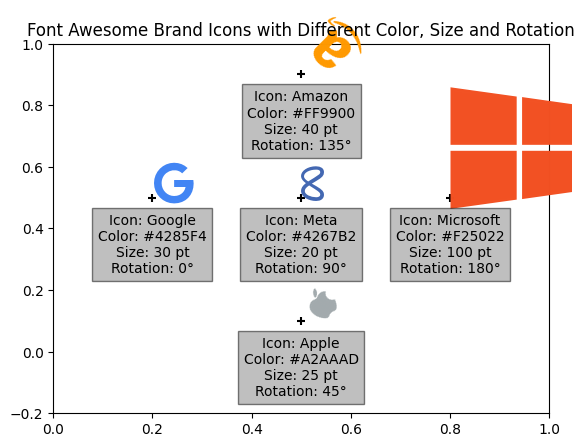

In [80]:
# Designate the icon to plot
icons = ["google", "apple", "meta", "amazon", "microsoft"]

# Designate the locations for each icon
xLoc = [0.2, 0.5, 0.5, 0.5, 0.8]
yLoc = [0.5, 0.1, 0.5, 0.9, 0.5]

# Specify color, size and rotation for each icon
icon_colors = ['#4285F4', '#A2AAAD', '#4267B2', '#FF9900', '#F25022']
font_sizes = [30, 25, 20, 40, 100]
icon_rotation = [0, 45, 90, 135, 180]

#| label: fig-gafam
#| fig-cap: "Google, Apple, Meta, Amazon and Microsoft icons plotted with different colors, sizes and rotations."

# Plot the figure with all the icons, colors, sizes and rotations
plt.figure()

for i in range(len(icons)):
    plt.text(xLoc[i], yLoc[i], fa_dict[icons[i]], fontproperties=fp_brands, color=icon_colors[i], fontsize=font_sizes[i], rotation=icon_rotation[i])
    
	# Scatter plot of icon locations
    plt.scatter(xLoc[i], yLoc[i], color='black', marker='+')

	# Description
    describe_now = f"Icon: {icons[i].capitalize()}\nColor: {icon_colors[i]}\nSize: {font_sizes[i]} pt\nRotation: {icon_rotation[i]}°"
    plt.text(xLoc[i], yLoc[i] - 0.05, describe_now, fontsize=10, ha='center', va='top', bbox=dict(facecolor='gray', alpha=0.5))

# Set the details of the plot before showing
plt.title("Font Awesome Brand Icons with Different Color, Size and Rotation")
plt.xlim(0, 1)
plt.ylim(-0.2, 1)
plt.show()

The coordinates where each icon was placed are indicated with a small black '+'. We see that the default placement is to align it at the lower left corner of each icon. 

We can specify the vertical and horizontal alignment of the text relative to the designated coordinates with the `'va'` and `'ha'` parameters. 

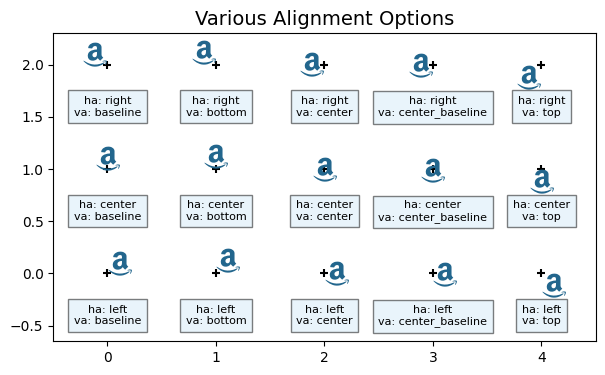

In [ ]:
# Various vertical and horizontal alignments to test
icon_va = ['baseline', 'bottom', 'center', 'center_baseline', 'top']
icon_ha = ['left', 'center', 'right']

#| label: fig-alignment
#| fig-cap: "Fifteen different combinations of horizontal and vertical alignments."

# Create figure
plt.figure(figsize=(7, 4))

# Plot the icons with different horizontal and vertical alignments

for i in range(len(icon_va)):
	for j in range(len(icon_ha)):
		plt.text(i, j, fa_dict["amazon"], fontproperties=fp_brands, fontsize=20, color='#22668D', ha=icon_ha[j], va=icon_va[i])
		plt.text(i, j - 0.3, f'ha: {icon_ha[j]}\nva: {icon_va[i]}', fontsize=8, ha='center', va='top', bbox=dict(facecolor='#D4EBF8', alpha=0.5))
		plt.scatter(i, j, color='black', marker='+')


# Use the unicode for 'coffee' (\uf0f4)
# plt.text(0.5, 0.5, fa_dict["google"], fontproperties=fp_brands, color='#22668D', fontsize=50, ha='center', va='center', rotation=45)
# plt.text(0.25, 0.5, fa_dict["apple"], fontproperties=fp_brands, fontsize=50, ha='left', va='baseline')
# plt.text(0.75, 0.5, fa_dict["meta"], fontproperties=fp_brands, fontsize=25, ha='left', va='bottom')

# Scatter plot
#plt.scatter([0.25, 0.5, 0.75], [0.5, 0.5, 0.5], color='red')

plt.xlim(-0.5, len(icon_va)-0.5)
plt.ylim(-0.65, len(icon_ha)-0.7)
plt.title("Various Alignment Options", fontsize=14)
plt.show()

Some of the vertical alignment options are quite similar. For example `'baseline'` is only slightly higher than `'bottom'`, and `'center_baseline'` looks to be a tiny bit higher than `'center'`. Perhaps the change may be more noticeable if you are working with larger icon sizes. 

Refer to the [`matplotlib` documentation on `pyplot.text()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html) for information on how to further customize icons as text.

However, plotting icons as text objects has its quirks. For example, you may have noticed in @fig-gafam that text objects are always placed on top of scatter plot markers, and they can overflow over the axis limits. 

## Drawing Icons on Plots as Paths{#sec-icon-path}

Converting Font Awesome icons into path objects allow us greater flexibility. We can use it as markers for scatter plots, keep it within the axis limits, designate different marker edge and face color, or apply an image overlay to it. We can even manually edit the vertices of the shape to show a fraction of an icon. 

No need to remember which font properties (font package) the original icon came from

### Convert Text to Paths

Convert the TextPath class from `matplotlib.text` to convert the Font Awesome text objects into a path.

Refer to the [`matplotlib` documentation on `text.TextPath`](https://matplotlib.org/3.5.3/api/textpath_api.html) for more information.

- My own function
- vertical and horizontal alignment
- show left half, right half, top half, bottom half

In [82]:
# Add a couple new entries to the dictionary
fa_dict.update({"church": '\uf51d', 
                "circle": '\uf111', 
                "fire": '\uf7e4',
                "moon": '\uf186', 
                "mound": '\ue52d', 
                "spiral": '\ue80a', 
                "star": '\uf005', 
                "water": '\uf773'})

In [81]:
# Import the TextPath class from matplotlib.text
from matplotlib.text import TextPath

Converting a Font Awesome icon from a text to a path requires:

- Offset position of the text
- Unicode identifier
- Font properties

In [ ]:
# Convert the two variants of the star icon to TextPath objects for use in plt.scatter
star_reg_path = TextPath((0, 0), fa_dict["star"], prop=fp_regular)
star_solid_path = TextPath((0, 0), fa_dict["star"], prop=fp_solid)

### Scatter Plot with Paths as Markers

The generated path can be used as a marker for the `plt.scatter()` function.

In [87]:
import numpy as np

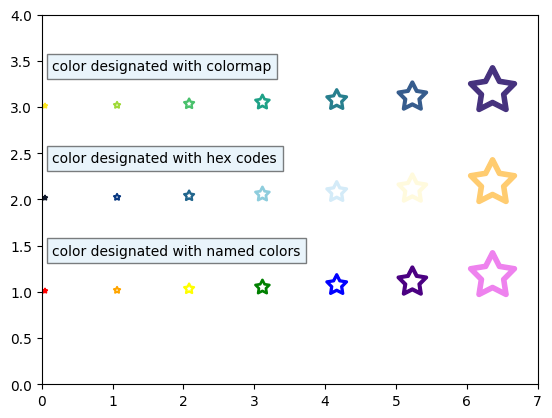

In [ ]:
# Modify size and color
marker_size = [50, 100, 250, 500, 1000, 2000, 5000]
icon_colors1 = ['red', 'orange', 'yellow', 'green', 'blue', 'indigo', 'violet']
icon_colors2 = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
icon_colors3 = plt.colormaps['viridis_r']

# Generate a figure
plt.figure()

# Generate the stars with the plt.scatter function
for i in range(0, len(marker_size)):
	plt.scatter(i, 1, color=icon_colors1[i], marker=star_reg_path, s=marker_size[i])
	plt.scatter(i, 2, color=icon_colors2[i], marker=star_reg_path, s=marker_size[i])
	plt.scatter(i, 3, color=icon_colors3(i/len(marker_size)), marker=star_reg_path, s=marker_size[i])

# Description
plt.text(0.15, 1.4, "color designated with named colors", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 2.4, "color designated with hex codes", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 3.4, "color designated with colormap", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.xlim(0, len(marker_size))
plt.ylim(0, 4)
plt.show()

We can designate the position of the icon, its color (`'c'` parameter), and its size (`'s'` parameter). The one thing that text objects could do that the scatter plot cannot do as easily is rotate the icons.

On the other hand, there are several features the icons can now do with the `plt.scatter()` function. Let's explore a couple of the options 

### Different Edge and Face Colors
`linewidth`
`edgecolor`

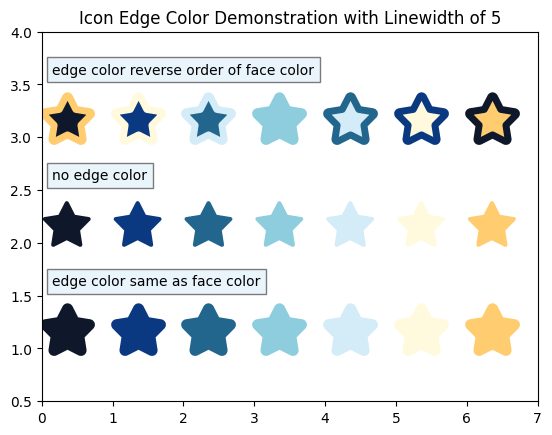

In [127]:
# Modify size and color
marker_size = 5000
icon_colors = ['#0F172A', '#0A3981', '#22668D', '#8ECDDD', '#D4EBF8', '#FFFADD', '#FFCC70']
edge_width = 5

# Generate a figure
plt.figure()

# Generate the stars with the plt.scatter function
for i in range(0, len(icon_colors)):
	plt.scatter(i, 1, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor='face', linewidth=edge_width)
	plt.scatter(i, 2, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor='none', linewidth=edge_width)
	plt.scatter(i, 3, color=icon_colors[i], marker=star_solid_path, s=marker_size, edgecolor=icon_colors[len(icon_colors)-i-1], linewidth=edge_width)

# Description
plt.text(0.15, 1.6, "edge color same as face color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 2.6, "no edge color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))
plt.text(0.15, 3.6, "edge color reverse order of face color", fontsize=10, bbox=dict(facecolor='#D4EBF8', alpha=0.5))

# Plot logistics
plt.title(f"Icon Edge Color Demonstration with Linewidth of {edge_width}")
plt.xlim(0, len(icon_colors))
plt.ylim(0.5, 4)
plt.show()

Playing around with `linewidth` and the `edgecolor` in the `plt.scatter()` function is useful especially with the solid icons. Setting `edgecolor='none'` keeps the icons sharp-looking at the points. Specifying `edgecolor='face'` can give a rounded impression to the icons. Designating a black or dark edgecolor can make icons with pale colors stand out. 

The creative flexibility of `edgecolor` and `linewidth` are features of `plt.scatter()` function that can be applied easily to Font Awesome icons that are converted to paths. Another feature of paths is in the precise assignment of offsets in its creation. These affect the horizontal and vertical alignment of the icons relative to the coordinates specified in `plt.scatter()`.

### Greater Precision in Horizontal and Vertical Alignment

We saw that text objects have various horizontal vertical alignment options in [the previous sections](#sec-ha-va-text). @fig-alignment showed fifteen different alignment options available with text objects. 

Alignment options are not available in the `plt.scatter()` function, but can be specified in the greation of the path objects with `text.TextPath` class. 

In [ ]:
# Convert the two variants of the star icon to TextPath objects for use in plt.scatter
moon_reg_path = TextPath((0, 0), fa_dict["moon"], prop=fp_regular)
moon_solid_path = TextPath((0, 0), fa_dict["moon"], prop=fp_solid)

Refer to the [official `matplotlib` documentation on `plt.scatter()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) for more information. 

### Plotting Half an Icon

In [ ]:
font_path = "C:/Users/jagar/Documents_Local/data/fontawesome-free-7.2.0-desktop/otfs/Font Awesome 7 Free-Solid-900.otf"
fp = FontProperties(fname=font_path)

font_path = "C:/Users/jagar/Documents_Local/data/fontawesome-free-7.2.0-desktop/otfs/Font Awesome 7 Free-Regular-400.otf"
fp2 = FontProperties(fname=font_path)

plt.figure(figsize=(6, 4))

# Use the unicode for 'coffee' (\uf0f4)
plt.text(0.5, 0.5, '\uf21a', fontproperties=fp, color='#22668D', fontsize=50, ha='center', va='center', rotation=45)
#plt.text(0.25, 0.5, '\uf21a', fontproperties=fp, fontsize=50, ha='left', va='baseline')
#plt.text(0.75, 0.5, '\uf21a', fontproperties=fp, fontsize=25, ha='left', va='bottom')

text_path = TextPath((-120, -120), '\uf21a', prop=fp, size=300)
#p1 = PathPatch(text_path, ec="w", lw=3, fc="w", alpha=0.9)

print(type(text_path))
#print(type(p1))

# Scatter plot
plt.scatter([0.25, 0.5, 0.75], [0.5, 0.5, 0.5], color='red', marker=text_path, s= 10000, edgecolors='green')

plt.title("Font Awesome in Matplotlib", fontsize=14)
plt.show()


### Bar Graph with Icons

- My own function to make horizontal or vertical bar graph 
	- Possible to move this bit into the blog post explaining the Pydy Tuesday 2026-05-05 on ships
	- Assume the icon is the same within the bar
- Stacked bar graph also possible (for another day?)

### Differences Between Text and Path

- Manual editing of shapes
- Fontsize vs marker size
- Outside the axis or cut off at axis
- Marker edge color
- Image clipping

## Fun plot of Starry Night	

### Image Overlay Method

## Summary